   step  train_batch_loss
0   100            3.8102
1   200            3.5515
2   300            3.5294
3   400            3.5297
4   500            3.3253
   epoch  num_epochs  train_loss  val_loss  val_exact  epoch_seconds
0      1           5      2.0873    0.6681     0.5200          280.0
1      2           5      0.5801    0.4520     0.6587          278.9
2      3           5      0.4430    0.3780     0.7015          280.2
3      4           5      0.3848    0.3383     0.7338          279.7
4      5           5      0.3463    0.3123     0.7530          279.0
test: {'test_loss': 0.3119, 'test_exact': 0.7535}


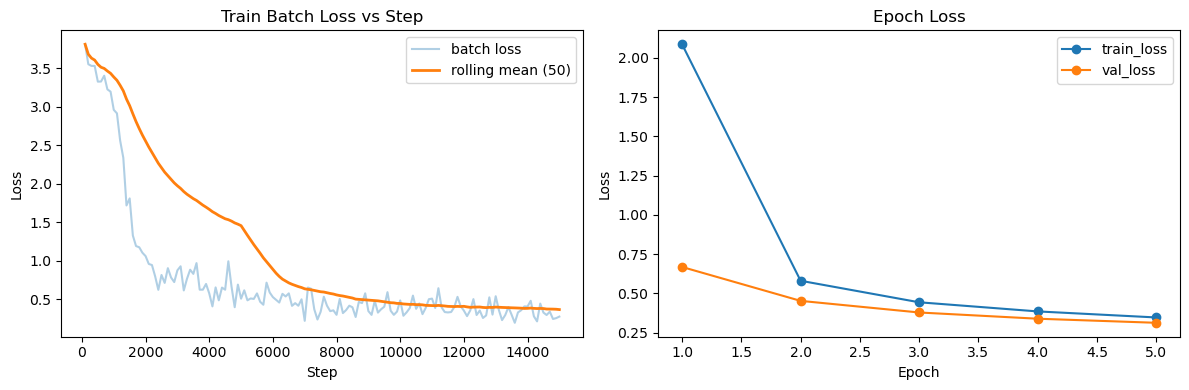

In [3]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

path = Path("C:/Users/Administrator/Downloads/480/CSC-480-Project/CNN/results.txt")
lines = path.read_text(encoding="utf-8").splitlines()

step_re = re.compile(r"^step=(\d+)\s+train_batch_loss=([0-9.]+)$")
epoch_re = re.compile(
    r"^Epoch\s+(\d+)/(\d+)\s+\|\s+train_loss=([0-9.]+)\s+train_exact=\S+\s+\|\s+val_loss=([0-9.]+)\s+val_exact=([0-9.]+)\s+\|\s+([0-9.]+)s$"
)
test_re = re.compile(r"^Test\s+\|\s+loss=([0-9.]+)\s+exact=([0-9.]+)$")

step_rows = []
epoch_rows = []
test_metrics = None

for line in lines:
    m = step_re.match(line)
    if m:
        step_rows.append({"step": int(m.group(1)), "train_batch_loss": float(m.group(2))})
        continue

    m = epoch_re.match(line)
    if m:
        epoch_rows.append({
            "epoch": int(m.group(1)),
            "num_epochs": int(m.group(2)),
            "train_loss": float(m.group(3)),
            "val_loss": float(m.group(4)),
            "val_exact": float(m.group(5)),
            "epoch_seconds": float(m.group(6)),
        })
        continue

    m = test_re.match(line)
    if m:
        test_metrics = {"test_loss": float(m.group(1)), "test_exact": float(m.group(2))}

df_steps = pd.DataFrame(step_rows)
df_epochs = pd.DataFrame(epoch_rows)

print(df_steps.head())
print(df_epochs)
print("test:", test_metrics)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(df_steps["step"], df_steps["train_batch_loss"], alpha=0.35, label="batch loss")
ax[0].plot(
    df_steps["step"],
    df_steps["train_batch_loss"].rolling(50, min_periods=1).mean(),
    linewidth=2,
    label="rolling mean (50)"
)
ax[0].set_title("Train Batch Loss vs Step")
ax[0].set_xlabel("Step")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(df_epochs["epoch"], df_epochs["train_loss"], marker="o", label="train_loss")
ax[1].plot(df_epochs["epoch"], df_epochs["val_loss"], marker="o", label="val_loss")
ax[1].set_title("Epoch Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()

plt.tight_layout()
plt.savefig("cnn_5epoch.png", dpi=150, bbox_inches="tight")
plt.show()
